# Patrones de desarrollo de los países — PCA y Clustering (WDI)

**TP Final — Análisis Multivariado y Descubrimiento de Patrones (Universidad Austral).**

Este notebook **consume** los resultados ya generados por el pipeline (`src/run_all.py`):
lee de `data/processed/` y `reports/figures/` y arma la narrativa. **No recalcula** todo.

Corte moderno **2023** (año macro estable, no post-COVID) y comparación con **2005**.

> Ejecutar antes: `python src/run_all.py`

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = ROOT / 'data' / 'processed'
FIG = ROOT / 'reports' / 'figures'
YM = 2023  # año moderno
pd.set_option('display.max_columns', 30)
print('Resultados desde:', PROC)

Resultados desde: d:\Users\Benja\Documents\Facultad Lic en ciencia de datos\3\analisis_multivariado\tp-pca-clustering-wdi\data\processed


## 1. Datos y cobertura

WDI del Banco Mundial, ~191 países, corte 2023 (+ 2005). **Año moderno = 2023** elegido por estabilidad macro (2021=rebote post-COVID, 2022=shock inflacionario) con cobertura adecuada. Variables descartadas: Gini, gasto en educación, INB-PPA.

In [2]:
cov = pd.read_csv(PROC / 'cobertura_por_anio.csv')
cov[['label', '2000', '2005', '2021', '2023']]

,label,2000,2005,2021,2023
0,PBI per capita (US$ const. 2015),0.917,0.935,0.959,0.931
1,INB per capita PPA ($ int. const.),0.535,0.571,0.908,0.700
2,Crecimiento anual del PBI (%),0.917,0.940,0.968,0.935
3,Inflacion anual al consumidor (%),0.751,0.816,0.820,0.811
4,Desempleo (% fuerza laboral),0.862,0.862,0.862,0.848
5,Formacion bruta de capital (% PBI),0.728,0.756,0.802,0.783
6,Exportaciones (% PBI),0.756,0.802,0.839,0.797
7,Importaciones (% PBI),0.756,0.802,0.839,0.797
8,"Agricultura, valor agregado (% PBI)",0.853,0.871,0.908,0.876
9,"Industria, valor agregado (% PBI)",0.829,0.862,0.922,0.885


## 2. EDA: transformaciones y correlación

Transformación decidida variable por variable según la asimetría observada.

,variable,transformacion,skew_antes,skew_despues
0,NY.GDP.PCAP.KD,log,2.175,-0.004
1,NY.GDP.MKTP.KD.ZG,yeojohnson,0.646,0.954
2,FP.CPI.TOTL.ZG,yeojohnson,9.467,-0.167
3,SL.UEM.TOTL.ZS,yeojohnson,1.696,0.000
4,NE.GDI.TOTL.ZS,none,-0.302,-0.302
5,NE.EXP.GNFS.ZS,yeojohnson,2.385,0.008
6,NE.IMP.GNFS.ZS,yeojohnson,2.104,0.038
7,NV.AGR.TOTL.ZS,yeojohnson,1.157,-0.027
8,NV.IND.TOTL.ZS,yeojohnson,0.977,0.022
9,NV.SRV.TOTL.ZS,none,0.155,0.155


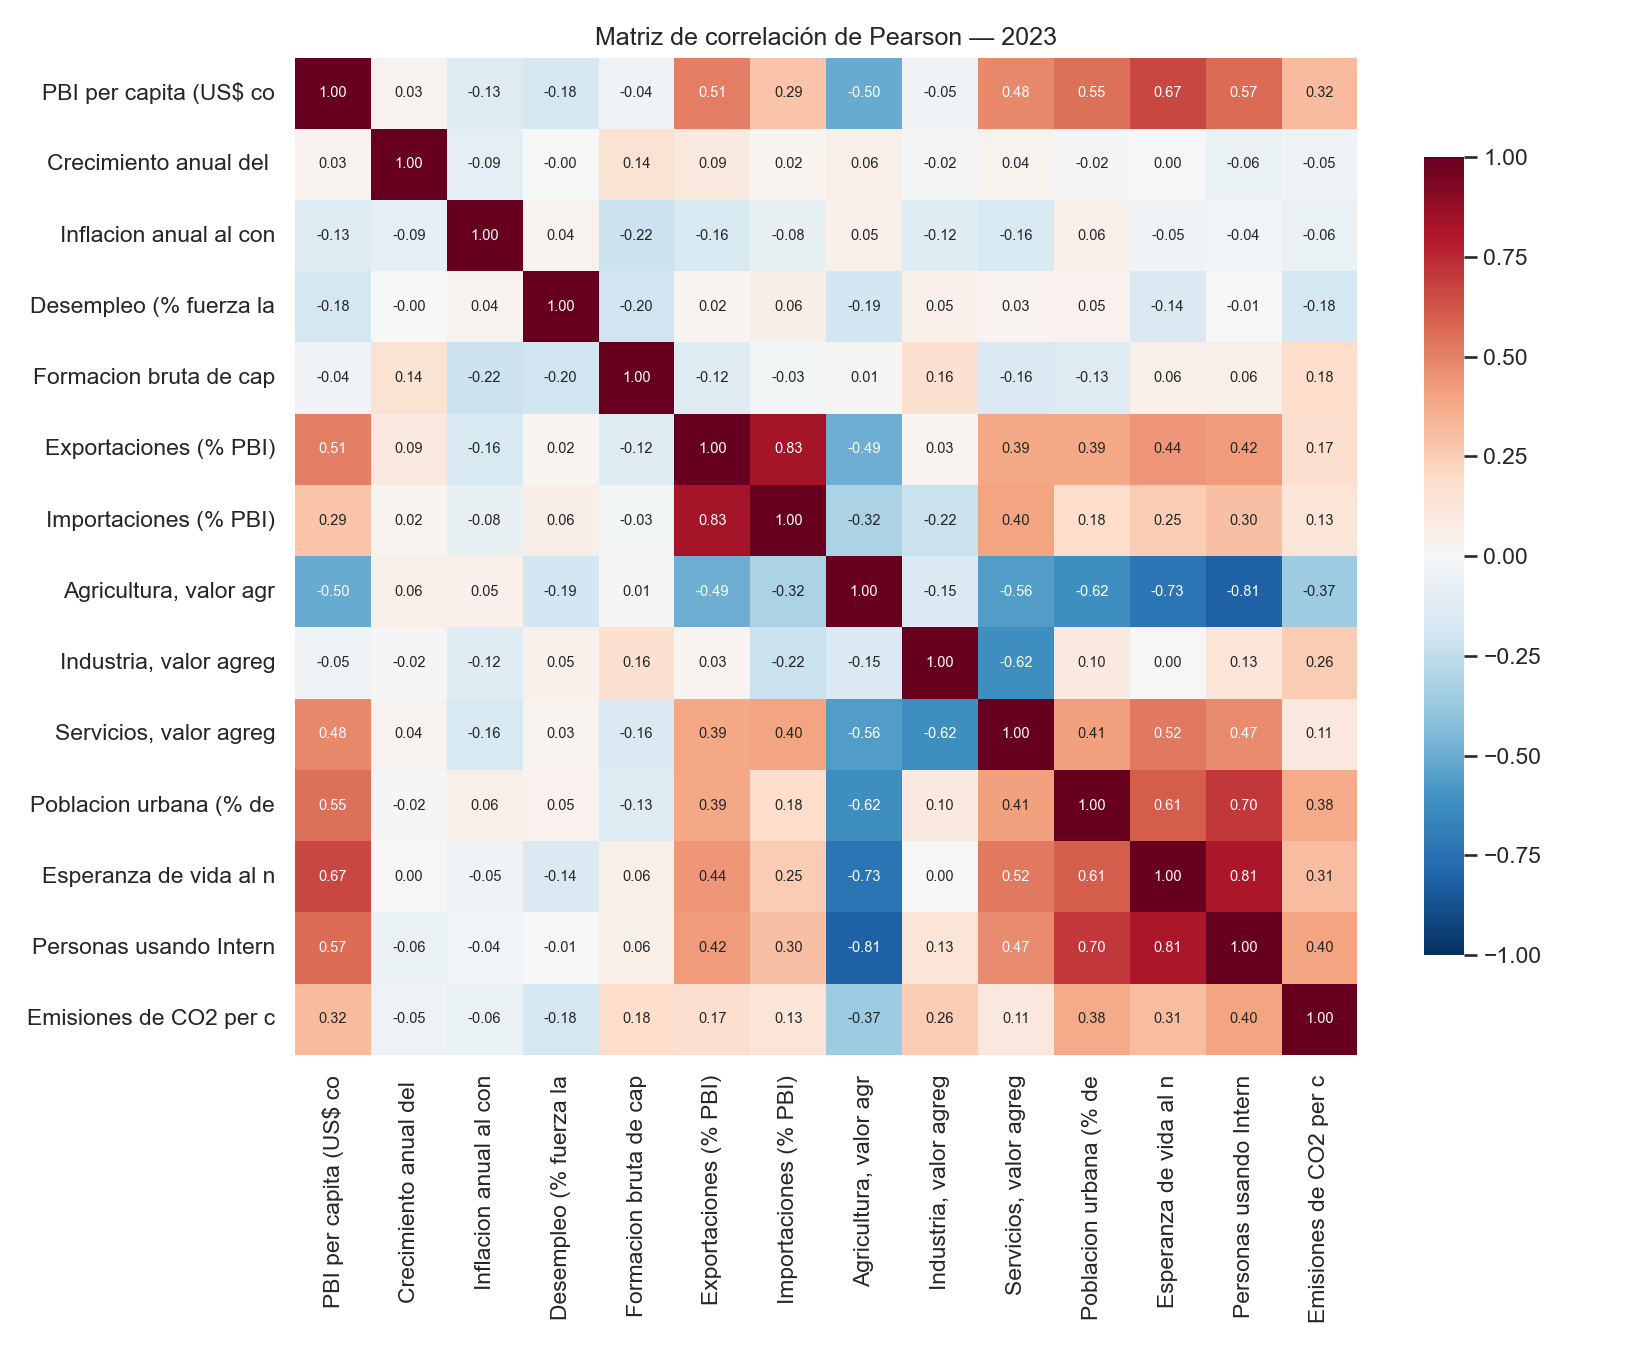

In [3]:
display(pd.read_csv(PROC / 'skewness_antes_despues.csv'))
display(Image(filename=str(FIG / f'eda_correlacion_{YM}.png')))

## 3. PCA

Retención por **análisis paralelo de Horn** (3 componentes). PC1 = gradiente de desarrollo (~41%). Nota: el PBI per cápita es **real** (constant 2015 US$).

Retención -> Kaiser: 4 | 80% var: 6 | Horn: 3
Componentes para clusterizar: 3 | para visualizar: 2


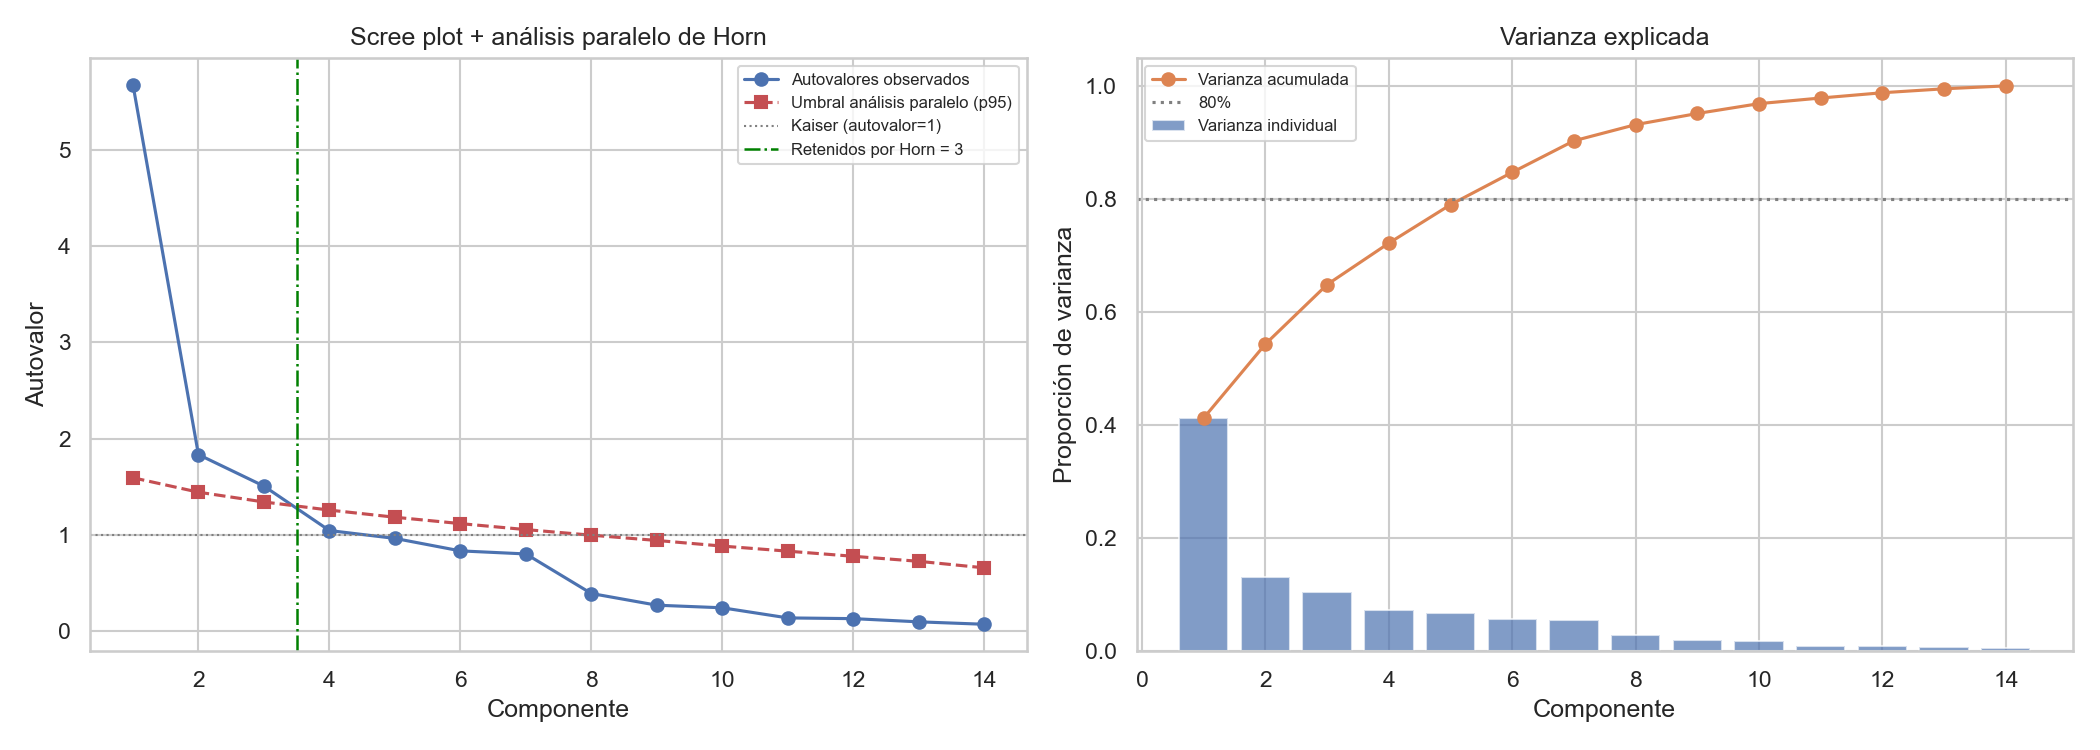

In [4]:
info = json.load(open(PROC / f'pca_info_{YM}.json', encoding='utf-8'))
print('Retención -> Kaiser:', info['kaiser'], '| 80% var:', info['n_80pct'], '| Horn:', info['parallel_analysis'])
print('Componentes para clusterizar:', info['n_clust'], '| para visualizar:', info['n_vis'])
display(Image(filename=str(FIG / f'pca_scree_{YM}.png')))

,PC1,PC2,PC3
NY.GDP.PCAP.KD,0.93,0.07,-0.08
NY.GDP.MKTP.KD.ZG,0.03,-0.12,0.56
FP.CPI.TOTL.ZG,-0.19,0.05,-0.55
SL.UEM.TOTL.ZS,0.06,-0.25,-0.12
NE.GDI.TOTL.ZS,0.02,0.37,0.44
NE.EXP.GNFS.ZS,0.70,-0.09,0.44
NE.IMP.GNFS.ZS,0.46,-0.37,0.51
NV.AGR.TOTL.ZS,-0.92,0.00,0.07
NV.IND.TOTL.ZS,-0.00,0.89,0.12
NV.SRV.TOTL.ZS,0.63,-0.64,-0.13


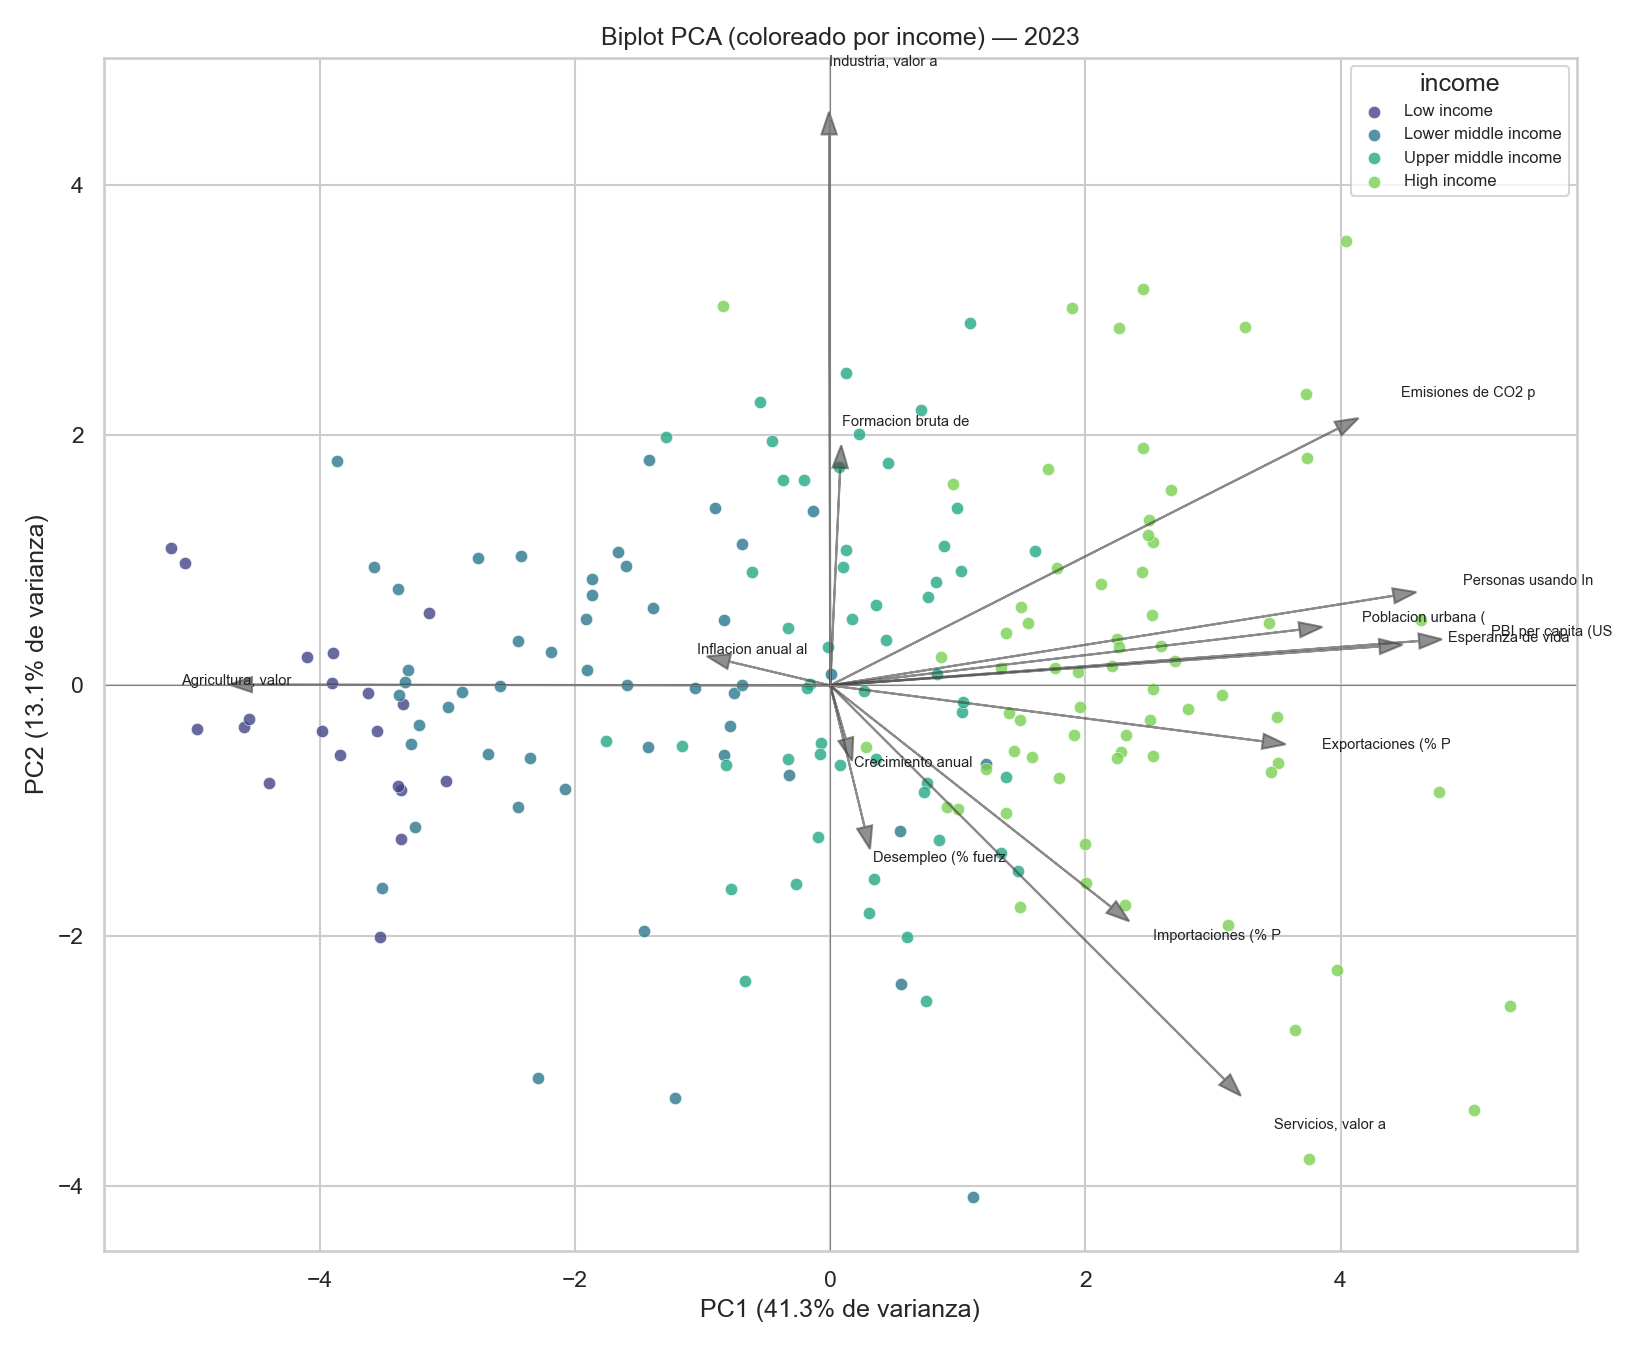

In [5]:
load = pd.read_csv(PROC / f'pca_loadings_{YM}.csv', index_col=0)
display(load.iloc[:, :3].round(2))
display(Image(filename=str(FIG / f'pca_biplot_ingreso_{YM}.png')))

## 4. Clustering

Principal: k-means sobre las **14 variables**. Comparación con PCA: **ARI 1,00** (la partición es la misma → el *tandem analysis* no sesga aquí). k=2 por consenso de métricas (incl. gap) + estabilidad.

Comparaciones k=2: {
  "ARI_kmeans_vs_ward_full": 0.6178774243926445,
  "ARI_full_vs_pca": 1.0,
  "silhouette_full": 0.277130696140447,
  "silhouette_pca": 0.39789752377089743
}
Estabilidad (Jaccard): {'2': {'0': 0.9601114249513211, '1': 0.936187582074925}, '3': {'0': 0.7331631538881848, '1': 0.7630049014831024, '2': 0.883755030932652}, '4': {'0': 0.7234677359427399, '1': 0.8861629211853894, '2': 0.6451052260501555, '3': 0.26659754435928834}}
Alternativas (GMM, HDBSCAN): {'ari_gmm2_vs_kmeans2': 0.6226651547953391, 'hdbscan_n_clusters': 2, 'hdbscan_frac_ruido': 0.5916230366492147}


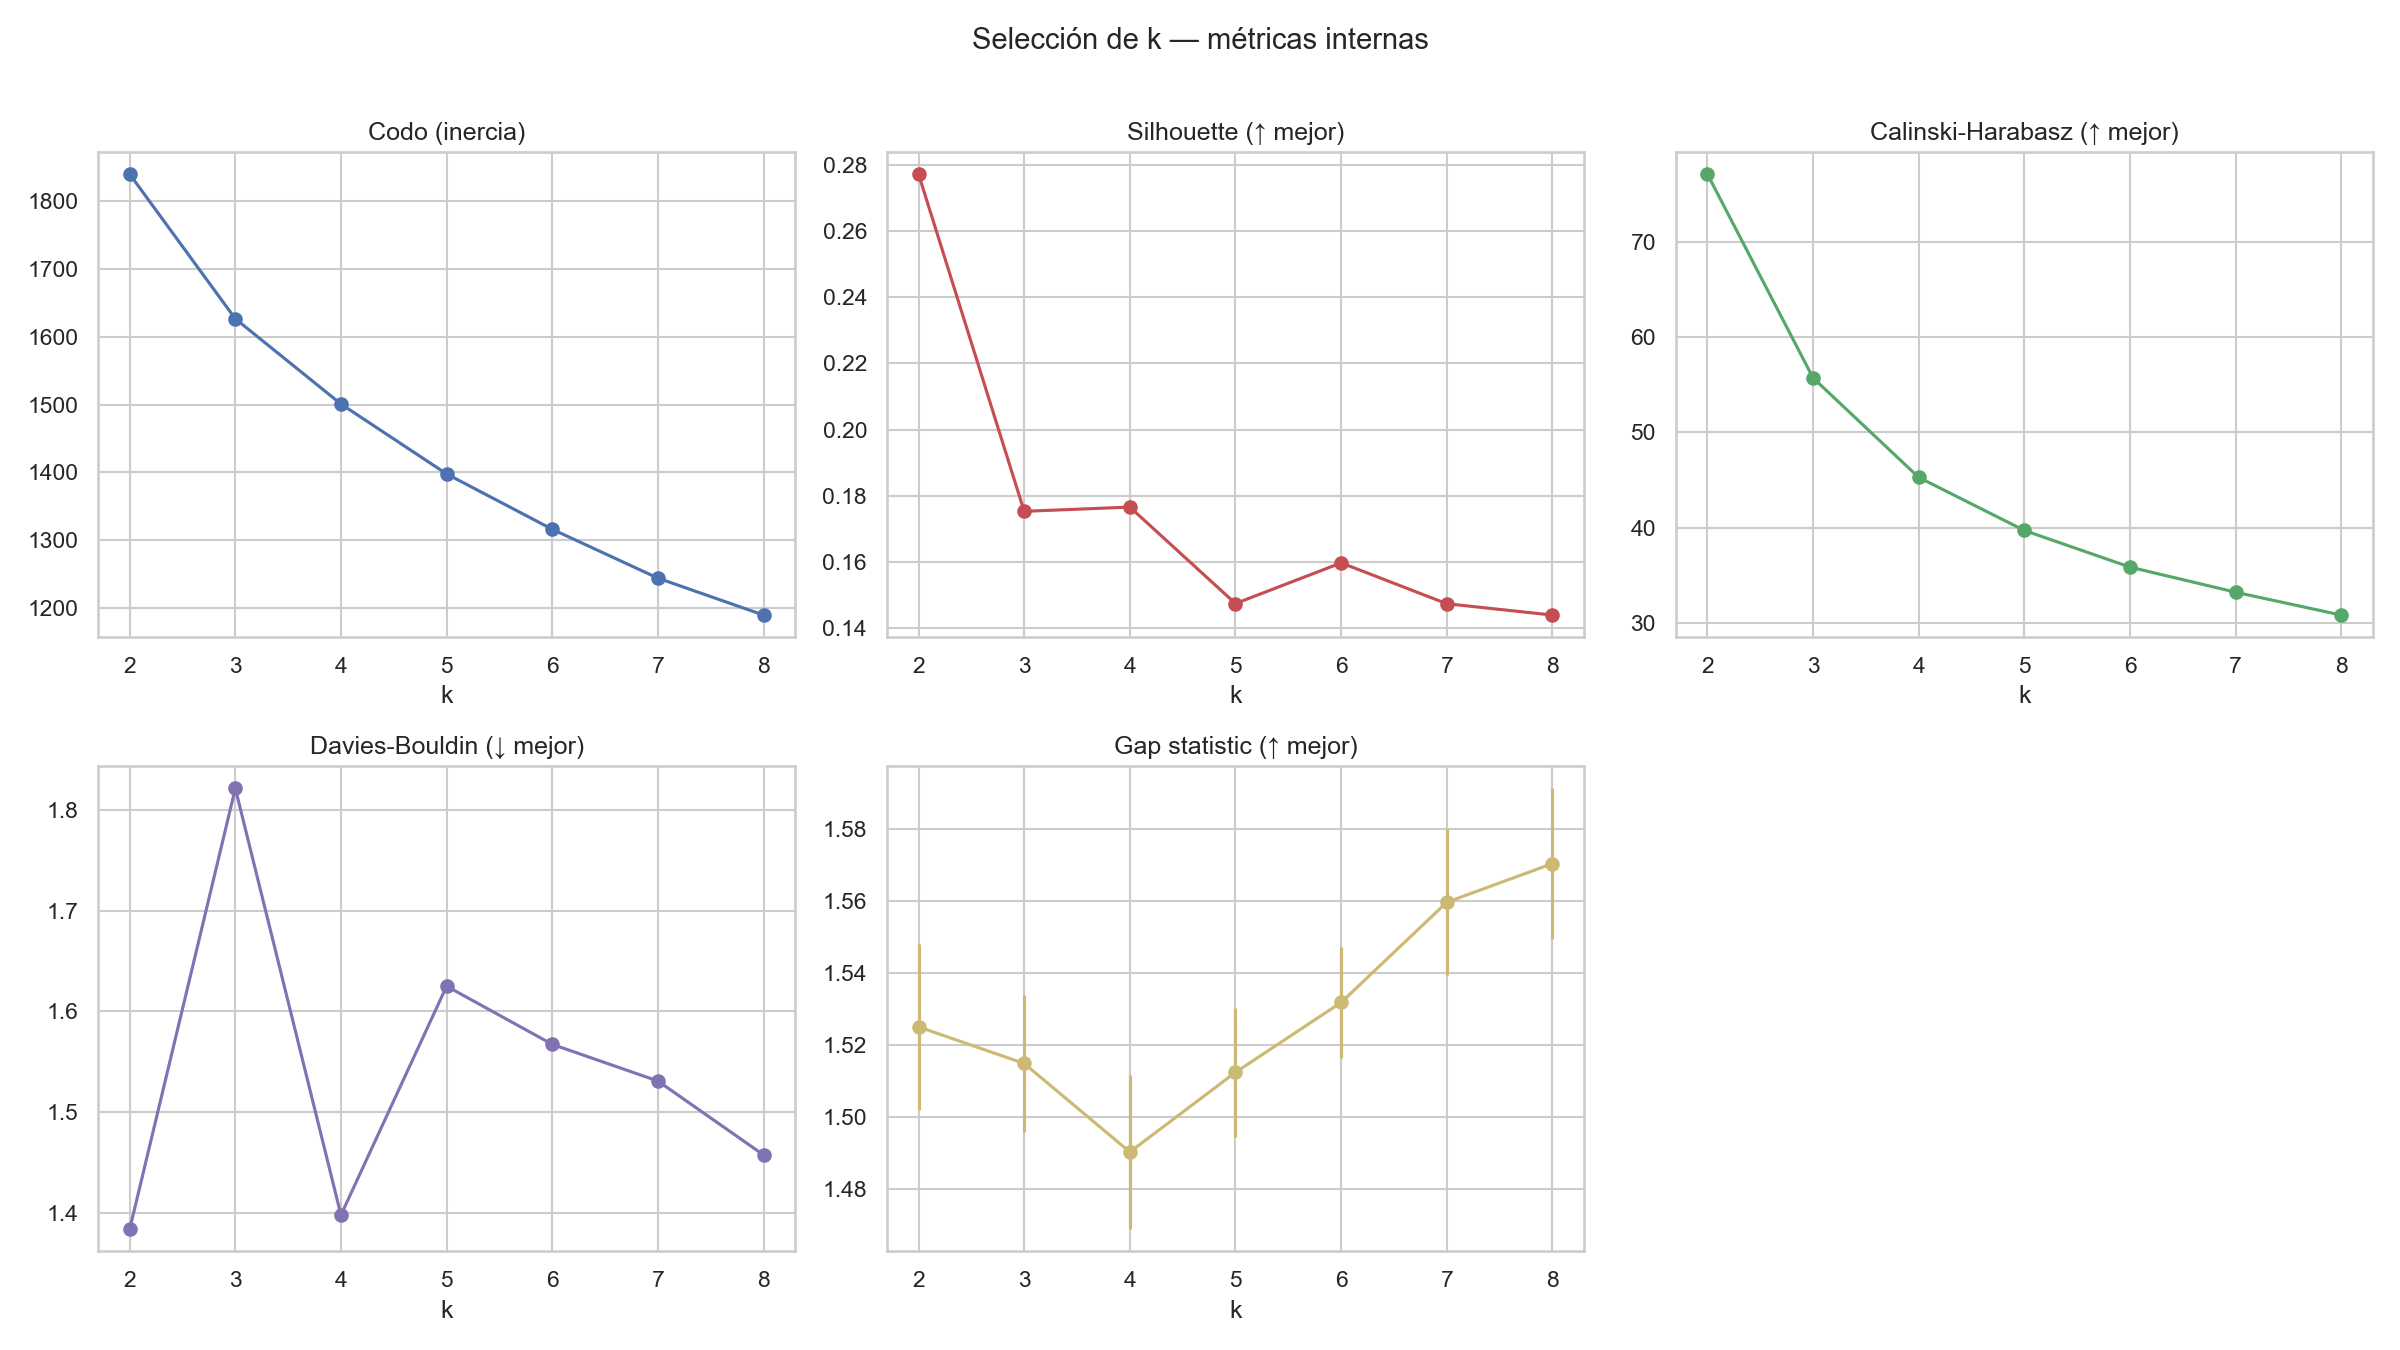

In [6]:
res = json.load(open(PROC / f'clustering_resultados_{YM}.json', encoding='utf-8'))
print('Comparaciones k=2:', json.dumps(res['comparaciones']['2'], indent=2, ensure_ascii=False))
print('Estabilidad (Jaccard):', res['estabilidad'])
print('Alternativas (GMM, HDBSCAN):', res['alternativas'])
display(Image(filename=str(FIG / f'clust_metricas_k_{YM}.png')))

Perfil de clusters (medianas, variables crudas) — k=2:


,0,1
PBI per capita (US$ const. 2015),1438.7,14932.9
Crecimiento anual del PBI (%),4.2,2.3
Inflacion anual al consumidor (%),7.1,5.0
Desempleo (% fuerza laboral),3.7,5.6
Formacion bruta de capital (% PBI),23.4,23.0
Exportaciones (% PBI),22.7,44.9
Importaciones (% PBI),34.4,50.9
"Agricultura, valor agregado (% PBI)",19.2,3.0
"Industria, valor agregado (% PBI)",25.5,24.2
"Servicios, valor agregado (% PBI)",48.0,60.3


Cruce cluster x nivel de ingreso:


,High income,Low income,Lower middle income,Not classified,Upper middle income
cluster,,,,,
0,1,20,42,1,6
1,66,0,7,1,47


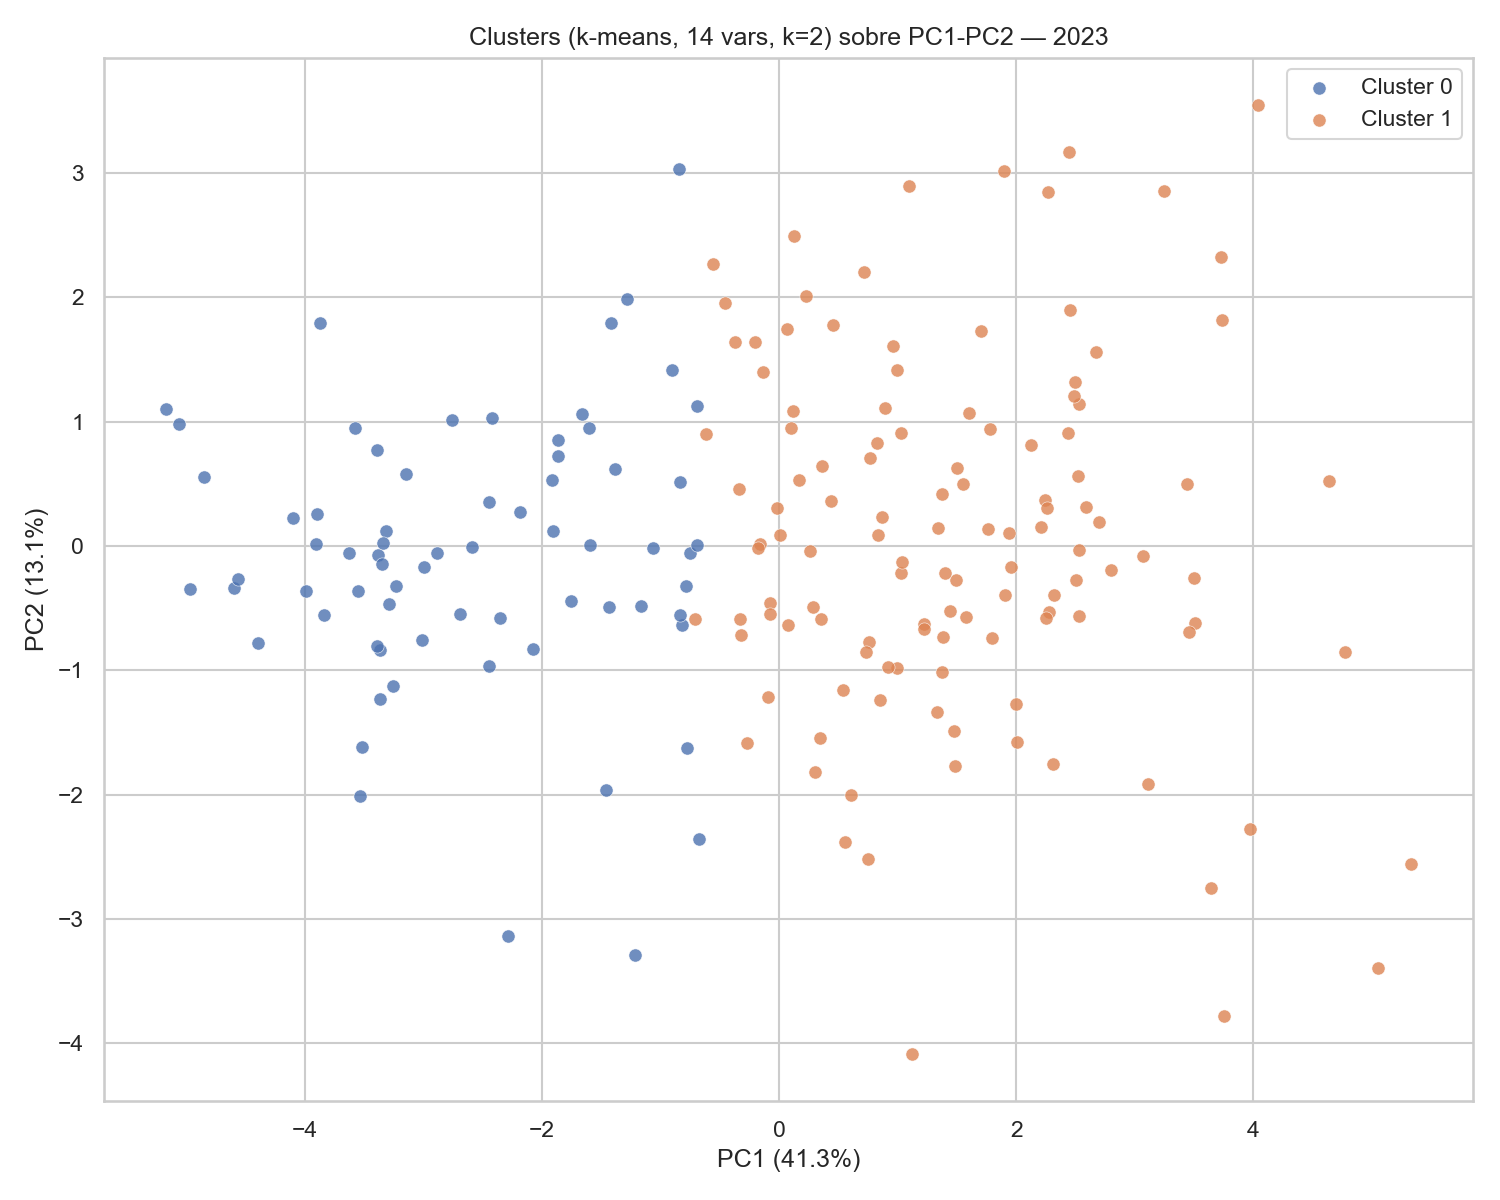

In [7]:
print('Perfil de clusters (medianas, variables crudas) — k=2:')
display(pd.read_csv(PROC / f'perfil_medianas_k2_{YM}.csv', index_col=0).round(1))
print('Cruce cluster x nivel de ingreso:')
display(pd.read_csv(PROC / f'cruce_ingreso_k2_{YM}.csv', index_col=0))
display(Image(filename=str(FIG / f'clust_pca_k2_{YM}.png')))

## 5. Comparación temporal 2005 vs 2023

Espacio común (un solo PCA sobre datos apilados). Casi todos los países avanzaron; 40 'graduaron' de cluster, ninguno regresó. La estructura (PC1) es muy estable (congruencia 0,96).

{
  "anio_early": 2005,
  "anio_modern": 2023,
  "evr_comun": [
    0.3880896028837406,
    0.12564592933460653,
    0.10797832544420308
  ],
  "ari_main_modern": 0.9789567766558686,
  "mov_medio_pc1": 0.9582151984734335,
  "congruencia_pc1": 0.9620667418100752,
  "corr_pc1": 0.9457453663905553,
  "evr_pc1_early": 0.4448943679299487,
  "evr_pc1_modern": 0.361569889165348,
  "n_cambian_cluster": 40,
  "dPC1_total_descomp": 0.9582151984734336
}


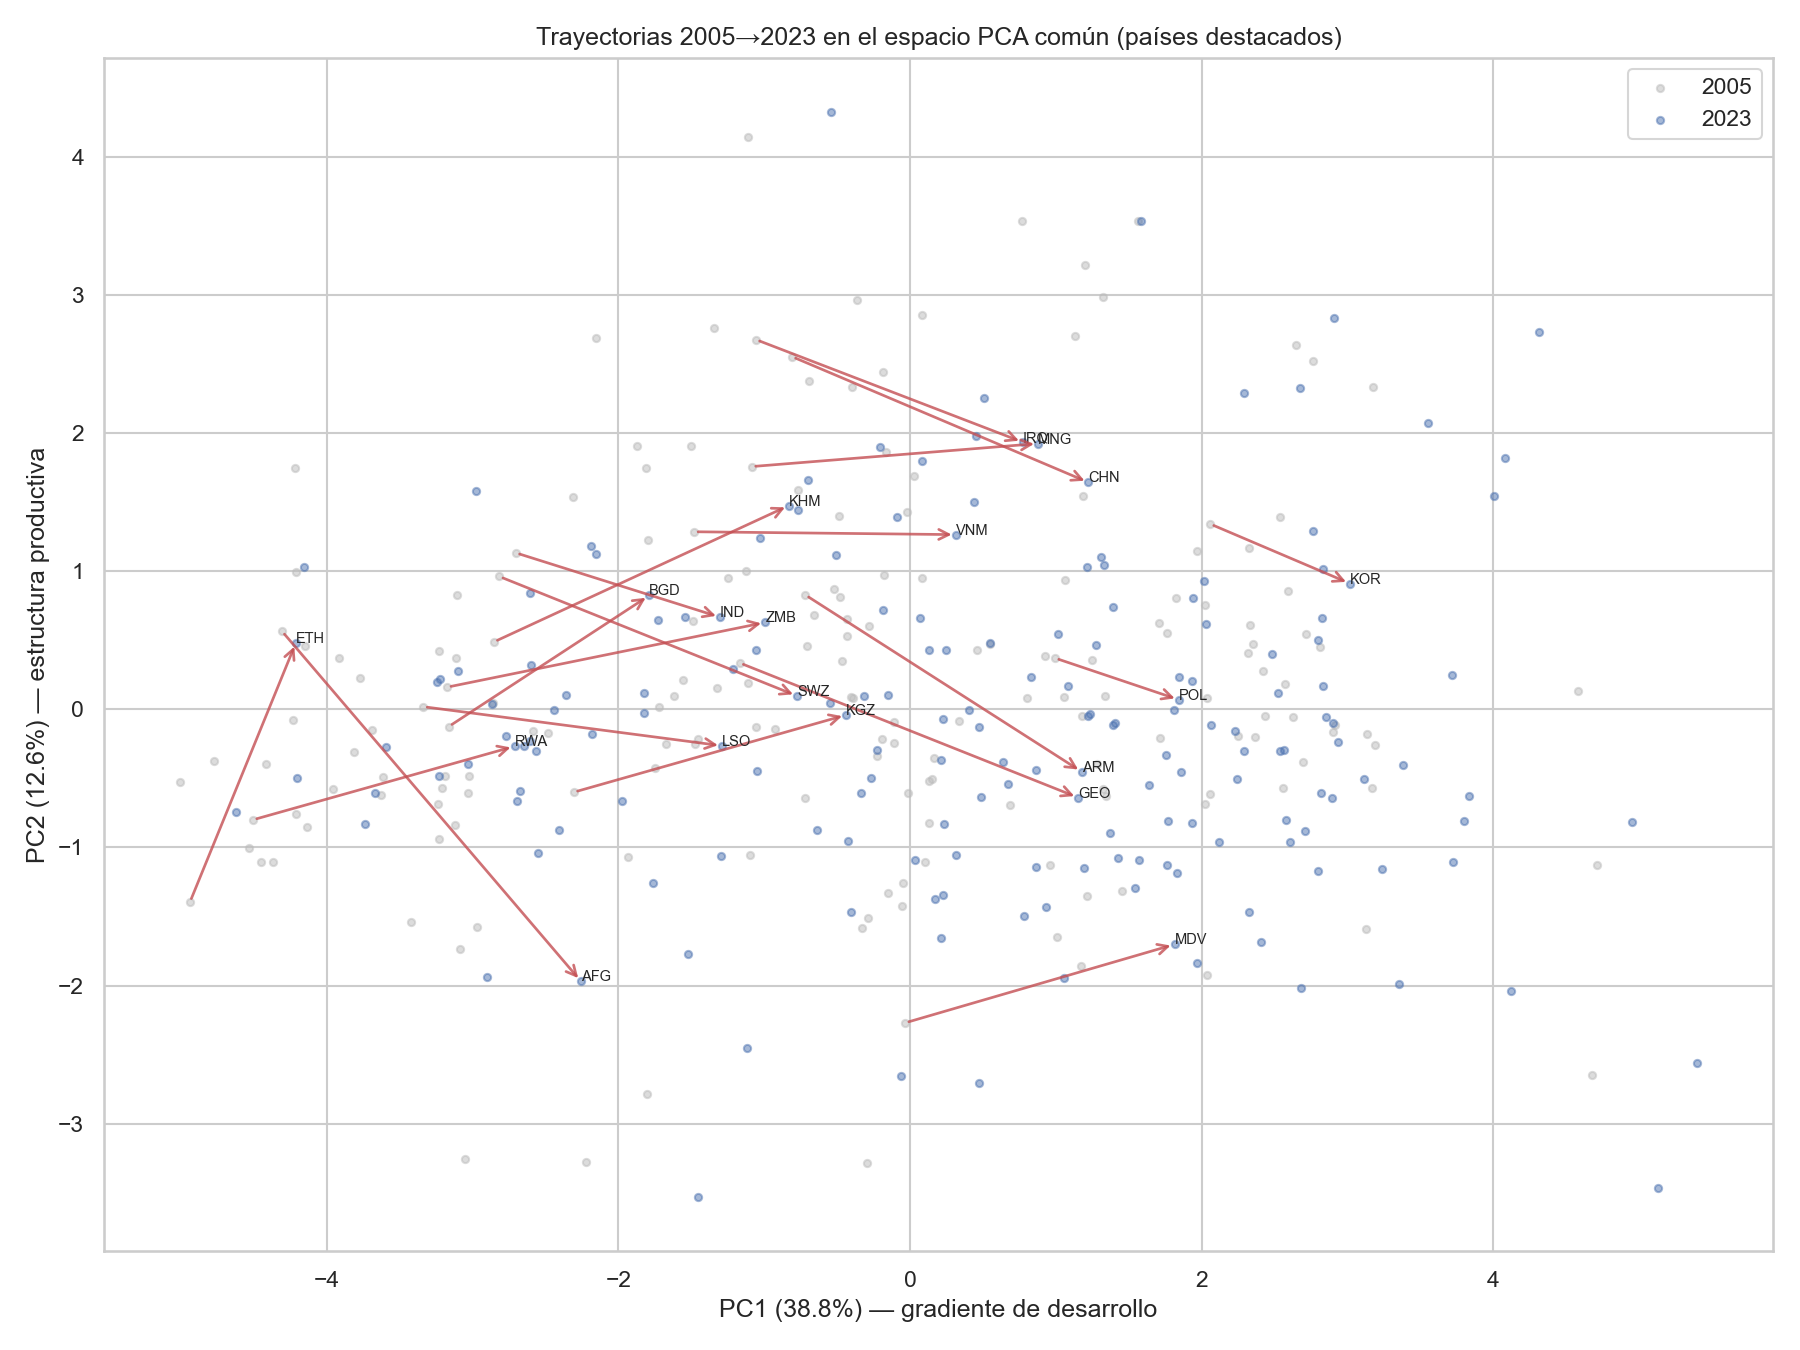

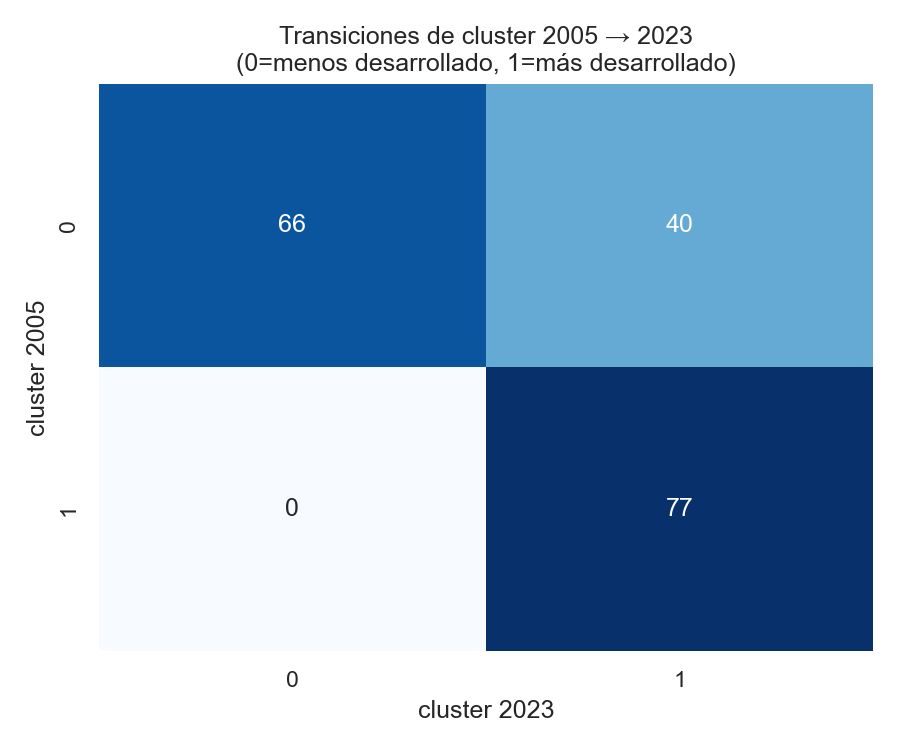

In [8]:
comp = json.load(open(PROC / 'compare_resultados.json', encoding='utf-8'))
print(json.dumps(comp, indent=2, ensure_ascii=False))
display(Image(filename=str(FIG / 'compare_trayectorias.png')))
display(Image(filename=str(FIG / 'compare_transiciones.png')))

### 5.a ¿PBI nominal distorsiona la lectura del avance?

**No.** (1) El PBI per cápita es **real** (constant 2015 US$). (2) Descomponiendo el avance medio en PC1, **Internet (47%)** y **esperanza de vida (22%)** lo dominan; el PBI real aporta solo **9%**. El avance es desarrollo genuino (conectividad, salud), no un artefacto de precios.

,variable,peso_PC1(w),mean_dz,contrib_a_dPC1,pct_del_total
0,Personas usando Internet (% poblacion),0.309,1.471,0.4542,47.4
1,Esperanza de vida al nacer (anios),0.375,0.567,0.2124,22.2
2,PBI per capita (US$ const. 2015),0.408,0.220,0.0900,9.4
3,Poblacion urbana (% del total),0.345,0.250,0.0862,9.0
4,"Servicios, valor agregado (% PBI)",0.274,0.256,0.0700,7.3
5,"Agricultura, valor agregado (% PBI)",-0.396,-0.158,0.0626,6.5
6,Importaciones (% PBI),0.172,0.082,0.0140,1.5
7,Exportaciones (% PBI),0.278,0.040,0.0111,1.2
8,Crecimiento anual del PBI (%),-0.031,-0.336,0.0105,1.1
9,Formacion bruta de capital (% PBI),0.057,0.016,0.0009,0.1


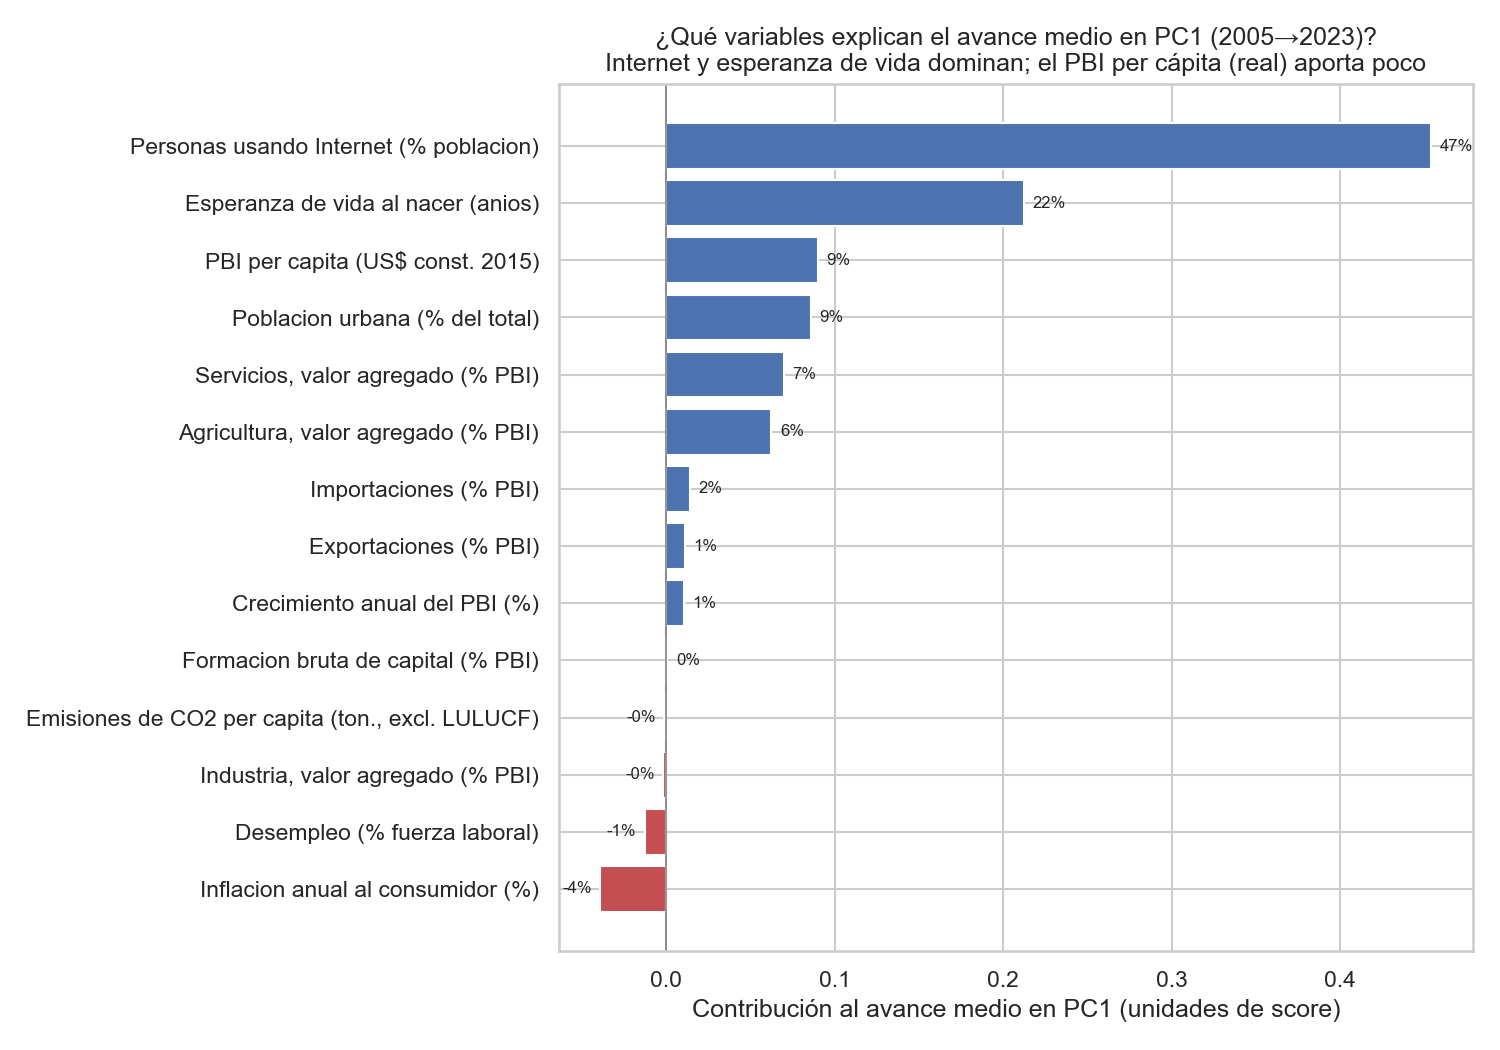

In [9]:
display(pd.read_csv(PROC / 'descomposicion_dPC1.csv'))
display(Image(filename=str(FIG / 'compare_descomposicion_dPC1.png')))

In [10]:
traj = pd.read_csv(PROC / 'trayectorias.csv')
print('Mayores avances en PC1 (gradiente de desarrollo):')
display(traj.sort_values('dPC1', ascending=False).head(8)[['country', 'cluster_e', 'cluster_m', 'dPC1']].round(2))
print('Mayores retrocesos:')
display(traj.sort_values('dPC1').head(5)[['country', 'cluster_e', 'cluster_m', 'dPC1']].round(2))

Mayores avances en PC1 (gradiente de desarrollo):


,country,cluster_e,cluster_m,dPC1
60,Georgia,0,1,2.32
181,Zambia,0,0,2.18
0,Afghanistan,0,0,2.05
100,Lesotho,0,0,2.05
158,Eswatini,0,0,2.04
31,China,0,1,2.03
90,Cambodia,0,0,2.02
116,Mongolia,0,1,1.97


Mayores retrocesos:


,country,cluster_e,cluster_m,dPC1
96,Lebanon,1,1,-0.74
177,"Venezuela, RB",1,1,-0.51
147,Sudan,0,0,-0.41
174,United States,1,1,-0.24
160,Chad,0,0,0.06


## 6. Sensibilidad

Robusto a imputación, nº de componentes y outliers. Único quiebre: **RobustScaler**, por amplificar el outlier de crecimiento de Macao (+75% en 2023) → justifica usar StandardScaler.

In [11]:
display(pd.read_csv(PROC / 'sensibilidad.csv'))

,variante,ARI_vs_base,corr_loadings_PC1,n
0,Imputación MICE,0.958,1.000,191
1,Casos completos (sin imputar),1.000,0.996,135
2,RobustScaler (todos),-0.004,0.009,191
3,RobustScaler (sin MAC),0.743,0.925,190
4,Clustering sobre 2 PCs,0.938,1.000,191
5,Clustering sobre 3 PCs,1.000,1.000,191
6,Clustering sobre 5 PCs,1.000,1.000,191
7,Sin outliers (10 países),0.934,0.982,181


## 7. Conclusiones

1. **PC1 (~41%)** resume el desarrollo como un **gradiente** (ingreso, salud, urbanización, conectividad vs peso agrario); PC2 = estructura productiva; PC3 = apertura/macro.
2. Clustering: **macro-separación robusta en 2 grupos** (desarrollado / en desarrollo), alineada con el ingreso del Banco Mundial, con excepciones informativas. El desarrollo es un **continuo**, no una taxonomía fina.
3. **2005→2023**: casi todos avanzaron (impulsado por **conectividad y salud**, no por el PBI —que además es real—); 40 graduaron, ninguno regresó; estructura muy estable (congruencia PC1 = 0,96).
4. Clusterizar sobre variables completas y **comparar** con PCA evita el sesgo del *tandem analysis* (aquí coinciden, ARI 1,00 — demostrado, no asumido).

Ver `reports/informe_borrador.md` y `reports/decisiones_metodologicas.md`.